## Install & Import Dependencies

In [2]:
# Install required packages
!pip install -q transformers torch torchvision pillow scikit-learn matplotlib seaborn pandas numpy

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import torch
import warnings
warnings.filterwarnings('ignore')

# CLIP from HuggingFace
from transformers import CLIPProcessor, CLIPModel

print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Load Dataset

In [4]:
# ── Step 1: Print the full /kaggle/input tree so we know exact paths ─────────
import os, glob

print('=== /kaggle/input directory tree ===')
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files[:15]:  # show up to 15 files per folder
        print(f'{indent}  {f}')

# ── Step 2: Find CSV and images by looking at what's actually there ───────────
# Find any CSV file
all_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print(f'\nAll CSVs found: {all_csvs}')

# Find any folder containing .jpg files
all_jpgs = glob.glob('/kaggle/input/**/*.jpg', recursive=True)
print(f'Sample JPGs found: {all_jpgs[:5]}')

if not all_csvs:
    raise FileNotFoundError('No CSV found in /kaggle/input — check the tree above and make sure the dataset is attached.')

# Pick the CSV (prefer one named 'styles')
CSV_PATH = next((c for c in all_csvs if 'styles' in os.path.basename(c).lower()), all_csvs[0])

# Images folder = folder that contains the jpg files
if all_jpgs:
    IMAGES_DIR = os.path.dirname(all_jpgs[0])
else:
    IMAGES_DIR = os.path.dirname(CSV_PATH)

print(f'\n CSV_PATH   = {CSV_PATH}')
print(f' IMAGES_DIR = {IMAGES_DIR}')

# ── Step 3: Load the dataframe ────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
print(f'\nColumns : {df.columns.tolist()}')
print(f'Shape   : {df.shape}')

id_col = 'id' if 'id' in df.columns else df.columns[0]
df['image_path'] = df[id_col].apply(lambda x: os.path.join(IMAGES_DIR, f'{x}.jpg'))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f'\n {len(df)} products with matching images')
df.head()

=== /kaggle/input directory tree ===
input/
  datasets/
    paramaggarwal/
      fashion-product-images-small/
        styles.csv
        myntradataset/
          styles.csv
          images/
            31973.jpg
            30778.jpg
            19812.jpg
            22735.jpg
            38246.jpg
            16916.jpg
            52876.jpg
            39500.jpg
            44758.jpg
            59454.jpg
            44951.jpg
            34410.jpg
            22706.jpg
            59735.jpg
            12666.jpg
        images/
          31973.jpg
          30778.jpg
          19812.jpg
          22735.jpg
          38246.jpg
          16916.jpg
          52876.jpg
          39500.jpg
          44758.jpg
          59454.jpg
          44951.jpg
          34410.jpg
          22706.jpg
          59735.jpg
          12666.jpg

All CSVs found: ['/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv', '/kaggle/input/datasets/paramaggarwal/fashion-product-images-sma

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...


## 🔧 Load CLIP Model & Build Embeddings

In [5]:
# Load CLIP (openai/clip-vit-base-patch32)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE)
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
model.eval()
print(' CLIP model loaded')

Using device: cuda


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

 CLIP model loaded


In [6]:
import transformers
import torch
from PIL import Image

print("Transformers version:", transformers.__version__)
print("Model class:", type(model))

inputs = processor(
    images=[Image.new("RGB", (224, 224))],
    return_tensors="pt"
).to(DEVICE)

try:
    out = model.get_image_features(pixel_values=inputs["pixel_values"])
    print("get_image_features type:", type(out))

    if isinstance(out, torch.Tensor):
        print("Tensor shape:", out.shape)
    else:
        print("Attributes:", [a for a in dir(out) if not a.startswith("_")][:30])

except Exception as e:
    print("Error from get_image_features:", e)

Transformers version: 5.0.0
Model class: <class 'transformers.models.clip.modeling_clip.CLIPModel'>
get_image_features type: <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
Attributes: ['attentions', 'clear', 'copy', 'fromkeys', 'get', 'hidden_states', 'items', 'keys', 'last_hidden_state', 'move_to_end', 'pooler_output', 'pop', 'popitem', 'setdefault', 'to_tuple', 'update', 'values']


In [7]:
from PIL import Image
import torch
import numpy as np

def embed_images(image_paths, batch_size=32):

    all_embeddings = []

    for i in range(0, len(image_paths), batch_size):

        batch_paths = image_paths[i:i+batch_size]

        images = []

        for path in batch_paths:
            try:
                images.append(Image.open(path).convert("RGB"))
            except:
                images.append(Image.new("RGB", (224,224)))

        inputs = processor(
            images=images,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():

            feats = model.get_image_features(
                pixel_values=inputs["pixel_values"]
            )

            # If returned object, extract embedding
            if not isinstance(feats, torch.Tensor):

                if hasattr(feats, "image_embeds"):
                    feats = feats.image_embeds

                elif hasattr(feats, "pooler_output"):
                    # DO NOT apply visual_projection again
                    feats = feats.pooler_output

                else:
                    raise RuntimeError(
                        f"Unknown output type: {type(feats)}"
                    )

            feats = torch.nn.functional.normalize(feats, dim=1)

        all_embeddings.append(feats.cpu().numpy())

        print(f"Embedded {min(i+batch_size,len(image_paths))}/{len(image_paths)}")

    return np.vstack(all_embeddings)

In [8]:
def embed_texts(texts):

    inputs = processor(
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {k:v.to(DEVICE) for k,v in inputs.items()}

    with torch.no_grad():

        feats = model.get_text_features(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        if not isinstance(feats, torch.Tensor):

            if hasattr(feats, "text_embeds"):
                feats = feats.text_embeds

            elif hasattr(feats, "pooler_output"):
                feats = feats.pooler_output

        feats = torch.nn.functional.normalize(feats, dim=1)

    return feats.cpu().numpy()

In [9]:
N_SAMPLES = 500

df_sub = df.sample(n=N_SAMPLES, random_state=7).copy().reset_index(drop=True)

print(f"Building CLIP embeddings for {N_SAMPLES} products...")

image_embeddings = embed_images(df_sub["image_path"].tolist())

print(image_embeddings.shape)

Building CLIP embeddings for 500 products...
Embedded 32/500
Embedded 64/500
Embedded 96/500
Embedded 128/500
Embedded 160/500
Embedded 192/500
Embedded 224/500
Embedded 256/500
Embedded 288/500
Embedded 320/500
Embedded 352/500
Embedded 384/500
Embedded 416/500
Embedded 448/500
Embedded 480/500
Embedded 500/500
(500, 512)


In [10]:
# ── Numpy-based vector index (no faiss required) ─────────────────────────────
class NumpyIndex:
    """Drop-in cosine similarity search using numpy (L2-normalised vectors)."""
    def __init__(self):
        self.vectors = None

    def add(self, vectors):
        self.vectors = vectors.astype('float32')

    def search(self, query, k):
        # query: (1, D), vectors: (N, D) — both L2-normalised → dot = cosine sim
        sims = (self.vectors @ query.T).squeeze()  # (N,)
        top_k_idx = np.argpartition(sims, -k)[-k:]
        top_k_idx = top_k_idx[np.argsort(sims[top_k_idx])[::-1]]
        top_k_scores = sims[top_k_idx]
        return top_k_scores[np.newaxis, :], top_k_idx[np.newaxis, :]

faiss_index = NumpyIndex()
faiss_index.add(image_embeddings)
print(f' NumpyIndex built with {len(image_embeddings)} vectors')

 NumpyIndex built with 500 vectors


---
# Task 1 – Smart Product Recommendation Engine 

**Approach:**  
We define **complementary product rules** grounded in fashion domain knowledge (e.g. Shoes → Socks, Watch).  
For each rule we embed a *descriptive text prompt* with CLIP and retrieve the top-k visually/semantically matching products from the catalog. This combines:
-  Rule-based domain logic  
-  Semantic CLIP embeddings  
-  Cosine similarity via FAISS


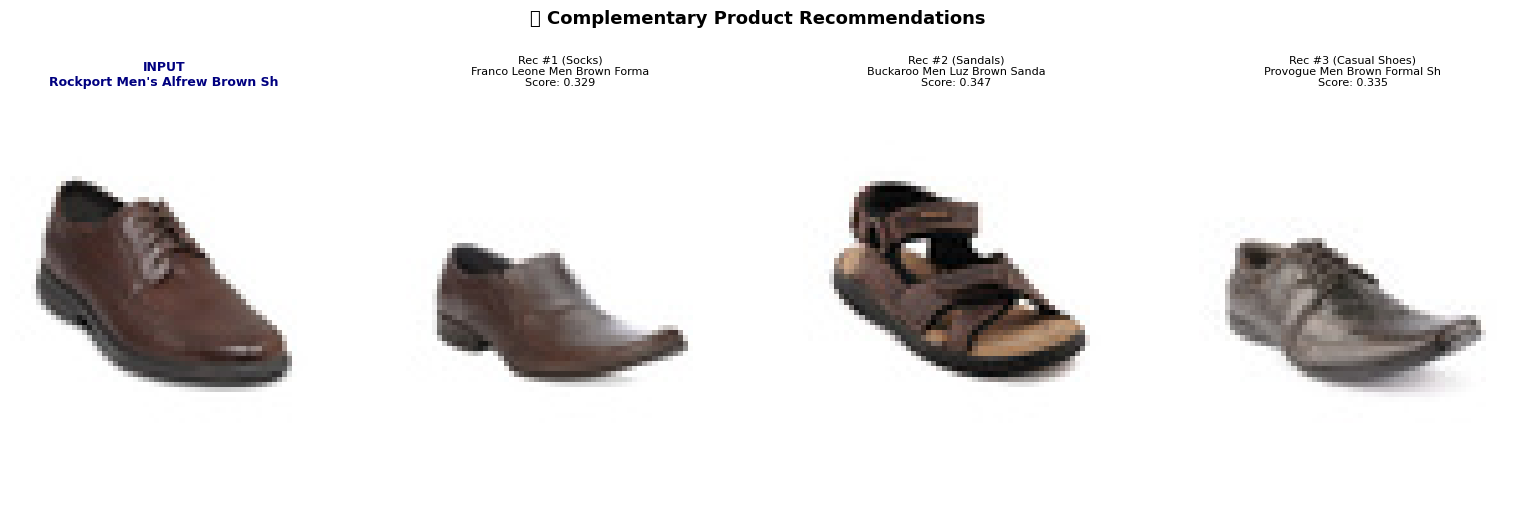


Recommendation details:
  ➜ Socks                → Franco Leone Men Brown Formal Shoes (score=0.329)
  ➜ Sandals              → Buckaroo Men Luz Brown Sandals (score=0.347)
  ➜ Casual Shoes         → Provogue Men Brown Formal Shoes (score=0.335)


In [11]:
# ── Complementary category rules ─────────────────────────────────────────────
COMPLEMENTARY_RULES = {
    'Shoes':       ['Socks', 'Sandals', 'Casual Shoes'],
    'Footwear':    ['Socks', 'Sports Shoes'],
    'Topwear':     ['Jeans', 'Trousers', 'Shorts'],
    'Shirts':      ['Trousers', 'Jeans', 'Belt'],
    'Jeans':       ['T-Shirts', 'Casual Shirts', 'Sneakers'],
    'Watches':     ['Wallets', 'Belts', 'Shirts'],
    'Bags':        ['Wallets', 'Casual Shoes', 'Sunglasses'],
    'Sunglasses':  ['Caps', 'T-Shirts'],
    'Kurtas':      ['Salwar', 'Churidar', 'Dupatta'],
}

def get_complementary_recommendations(product_idx, df_catalog, embeddings, top_k=3):
    """
    Given a product index, find complementary products.
    Strategy:
      1. Look up product's subCategory / articleType.
      2. Match to COMPLEMENTARY_RULES to get target types.
      3. For each target type, embed a text query and search the FAISS index.
      4. Filter results to match the target subCategory.
    """
    row = df_catalog.iloc[product_idx]
    product_name = str(row.get('productDisplayName', row.get('articleType', 'product')))
    sub_cat  = str(row.get('subCategory', ''))
    art_type = str(row.get('articleType', ''))

    # Find matching rule key
    matched_targets = []
    for key, targets in COMPLEMENTARY_RULES.items():
        if key.lower() in sub_cat.lower() or key.lower() in art_type.lower():
            matched_targets.extend(targets)

    if not matched_targets:
        # Fallback: generic complementary items
        matched_targets = ['Accessories', 'Belt', 'Wallet']

    recommendations = []
    seen_indices = {product_idx}

    for target_type in matched_targets[:top_k]:
        # Build a descriptive text prompt for the target
        text_prompt = f'a {target_type} that goes well with {product_name}'
        text_emb = embed_texts([text_prompt]).astype('float32')

        # Search FAISS
        scores, indices = faiss_index.search(text_emb, 10)

        for score, idx in zip(scores[0], indices[0]):
            if idx not in seen_indices and idx < len(df_catalog):
                seen_indices.add(idx)
                rec_row = df_catalog.iloc[idx]
                recommendations.append({
                    'product_idx':   idx,
                    'name':          rec_row.get('productDisplayName', rec_row.get('articleType', '?')),
                    'category':      rec_row.get('subCategory', ''),
                    'article_type':  rec_row.get('articleType', ''),
                    'target_type':   target_type,
                    'score':         float(score),
                    'image_path':    rec_row['image_path'],
                })
                break  # one recommendation per target type

    return product_name, recommendations


def visualize_recommendations(product_idx, df_catalog, embeddings, top_k=3):
    product_name, recs = get_complementary_recommendations(product_idx, df_catalog, embeddings, top_k)
    n_cols = top_k + 1  # input + recommendations
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))

    # Input product
    input_img = Image.open(df_catalog.iloc[product_idx]['image_path']).convert('RGB')
    axes[0].imshow(input_img)
    axes[0].set_title(f'INPUT\n{product_name[:30]}', fontsize=9, fontweight='bold', color='navy')
    axes[0].axis('off')
    # Highlight border
    for spine in axes[0].spines.values():
        spine.set_edgecolor('navy'); spine.set_linewidth(3)

    # Recommendations
    for i, rec in enumerate(recs[:top_k]):
        ax = axes[i + 1]
        try:
            img = Image.open(rec['image_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (200, 200, 200))
        ax.imshow(img)
        ax.set_title(
            f'Rec #{i+1} ({rec["target_type"]})\n{str(rec["name"])[:28]}\nScore: {rec["score"]:.3f}',
            fontsize=8
        )
        ax.axis('off')

    plt.suptitle('🛒 Complementary Product Recommendations', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('task1_recommendations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nRecommendation details:')
    for r in recs:
        print(f"  ➜ {r['target_type']:20s} → {str(r['name'])[:40]} (score={r['score']:.3f})")


# ── Demo: pick the first product and get recommendations ─────────────────────
DEMO_IDX = 17
visualize_recommendations(DEMO_IDX, df_sub, image_embeddings, top_k=3)


--- Product index 42 ---


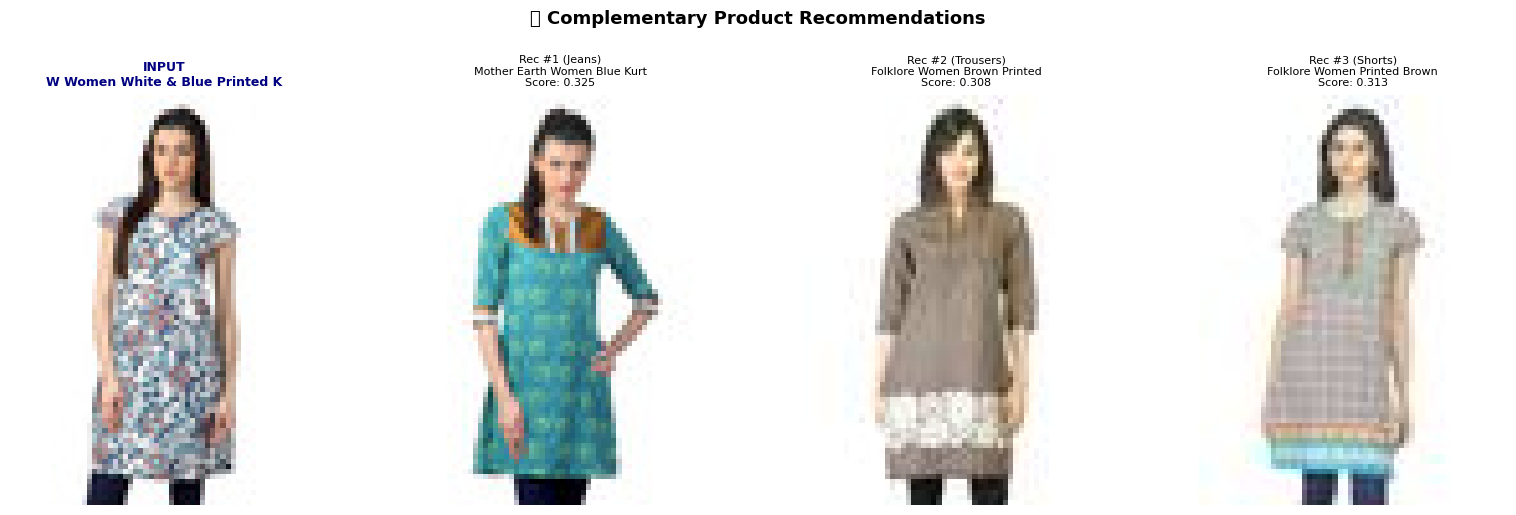


Recommendation details:
  ➜ Jeans                → Mother Earth Women Blue Kurta (score=0.325)
  ➜ Trousers             → Folklore Women Brown Printed Kurta (score=0.308)
  ➜ Shorts               → Folklore Women Printed Brown Kurta (score=0.313)

--- Product index 88 ---


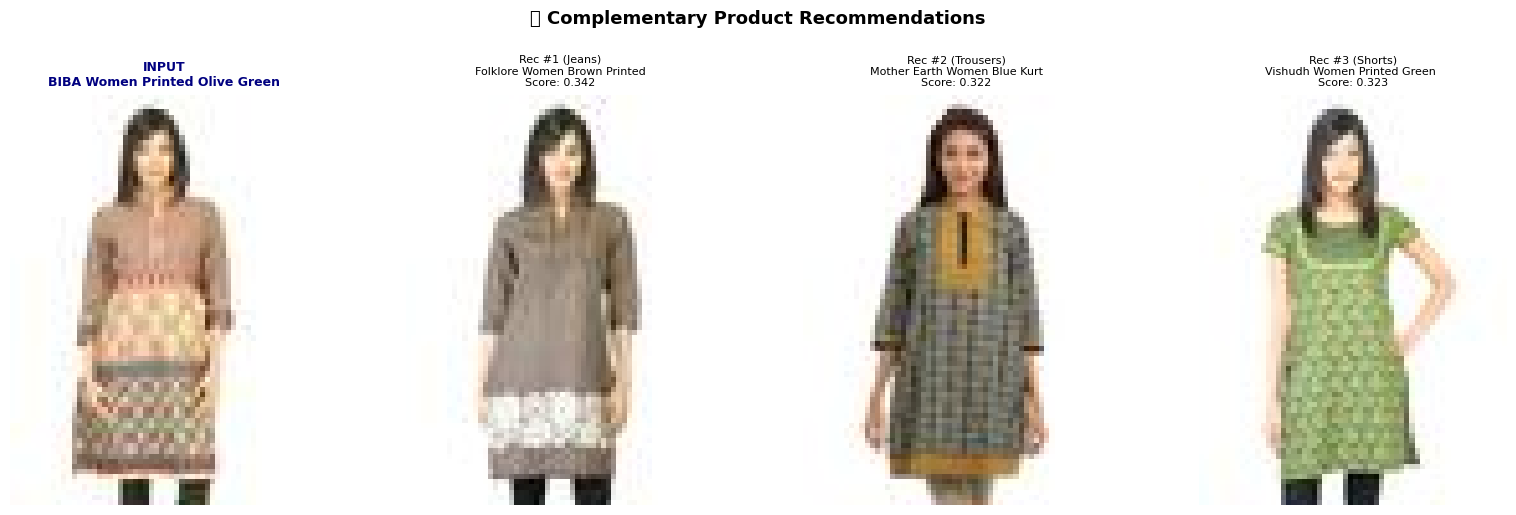


Recommendation details:
  ➜ Jeans                → Folklore Women Brown Printed Kurta (score=0.342)
  ➜ Trousers             → Mother Earth Women Blue Kurta (score=0.322)
  ➜ Shorts               → Vishudh Women Printed Green Kurta (score=0.323)

--- Product index 133 ---


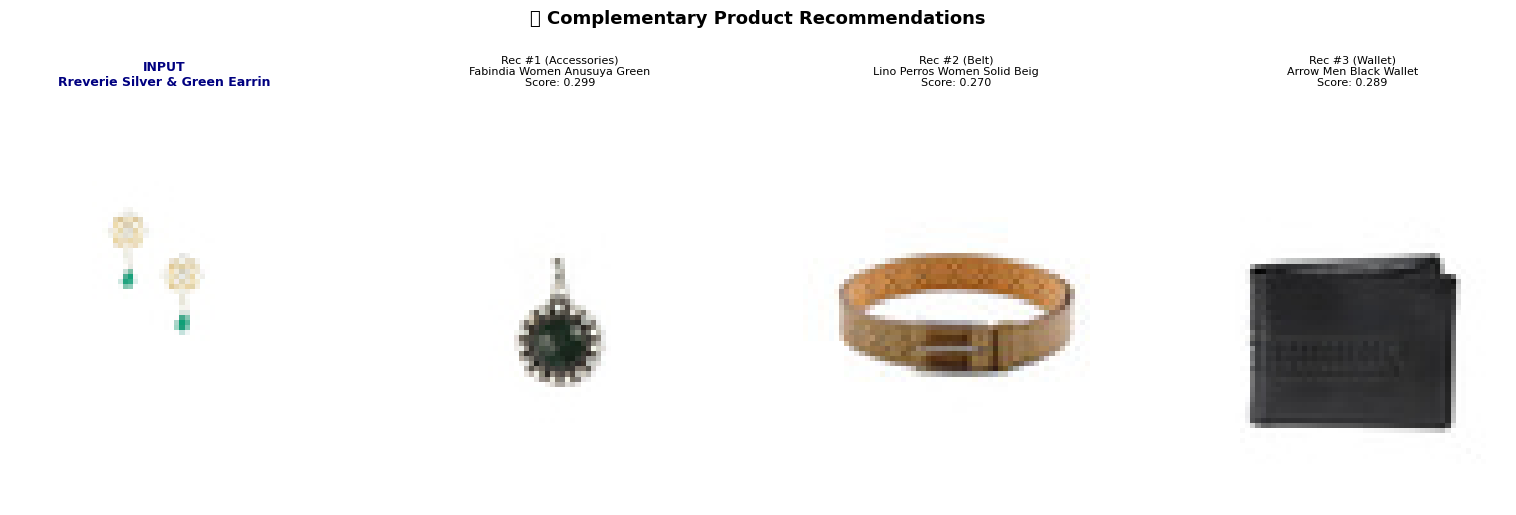


Recommendation details:
  ➜ Accessories          → Fabindia Women Anusuya Green Pendant (score=0.299)
  ➜ Belt                 → Lino Perros Women Solid Beige Belt (score=0.270)
  ➜ Wallet               → Arrow Men Black Wallet (score=0.289)


In [12]:
# Try a few more demo products
for demo_idx in [42, 88, 133]:
    print(f'\n--- Product index {demo_idx} ---')
    visualize_recommendations(demo_idx, df_sub, image_embeddings, top_k=3)

---
# Task 2 – Unique Product Catalog Creation 

**Approach:**  
1. Compute CLIP image embeddings for all products (already done above).  
2. Apply **Agglomerative Clustering** with a cosine distance threshold to group near-duplicates.  
3. Select one representative per cluster → **clean unique catalog**.

This is threshold-based deduplication: two products whose embeddings have cosine similarity > `SIMILARITY_THRESHOLD` are considered duplicates.


In [13]:
SIMILARITY_THRESHOLD = 0.92  # tweak: higher = fewer merges (stricter uniqueness)
DISTANCE_THRESHOLD   = 1.0 - SIMILARITY_THRESHOLD  # cosine distance

print(f'Clustering {len(df_sub)} products with cosine distance threshold = {DISTANCE_THRESHOLD:.2f} …')

clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=DISTANCE_THRESHOLD,
    metric='cosine',
    linkage='average'
)
cluster_labels = clustering.fit_predict(image_embeddings)

df_sub['cluster_id'] = cluster_labels
n_clusters = df_sub['cluster_id'].nunique()
print(f' Found {n_clusters} unique product clusters from {len(df_sub)} items')
print(f'   Duplication rate: {(1 - n_clusters/len(df_sub))*100:.1f}%')

Clustering 500 products with cosine distance threshold = 0.08 …
 Found 344 unique product clusters from 500 items
   Duplication rate: 31.2%


In [14]:
# ── Build unique catalog: pick one representative per cluster ─────────────────
# Representative = product with the highest average similarity to cluster members

unique_catalog_rows = []

for cid in sorted(df_sub['cluster_id'].unique()):
    mask    = df_sub['cluster_id'] == cid
    indices = df_sub.index[mask].tolist()
    cluster_embeds = image_embeddings[indices]

    if len(indices) == 1:
        rep_local = 0
    else:
        sim_matrix  = cosine_similarity(cluster_embeds)
        mean_sims   = sim_matrix.mean(axis=1)
        rep_local   = int(np.argmax(mean_sims))

    rep_global = indices[rep_local]
    row = df_sub.iloc[rep_global].to_dict()
    row['cluster_size'] = len(indices)
    unique_catalog_rows.append(row)

unique_catalog = pd.DataFrame(unique_catalog_rows).reset_index(drop=True)
print(f'\nUnique Catalog: {len(unique_catalog)} products')
print(unique_catalog[['productDisplayName', 'subCategory', 'articleType', 'cluster_size']].head(20).to_string())


Unique Catalog: 344 products
                                     productDisplayName subCategory   articleType  cluster_size
0                     Vishudh Women Printed Green Kurta     Topwear        Kurtas             3
1                                   Vans Men Grey Shoes       Shoes  Casual Shoes             3
2                      Probase Men Printed Blue Tshirts     Topwear       Tshirts             2
3                              Baggit Women Purple Belt       Belts         Belts             3
4                      Nike Men Casual Grey Sweatshirts     Topwear   Sweatshirts             2
5                         Mother Earth Women Blue Kurta     Topwear        Kurtas             2
6   Puma Men Future Cat Remix Lo Navy Blue Casual Shoes       Shoes  Casual Shoes             2
7                    Murcia Women Casual Maroon Handbag        Bags      Handbags             6
8   United Colors of Benetton Men Printed White Tshirts     Topwear       Tshirts             3
9         

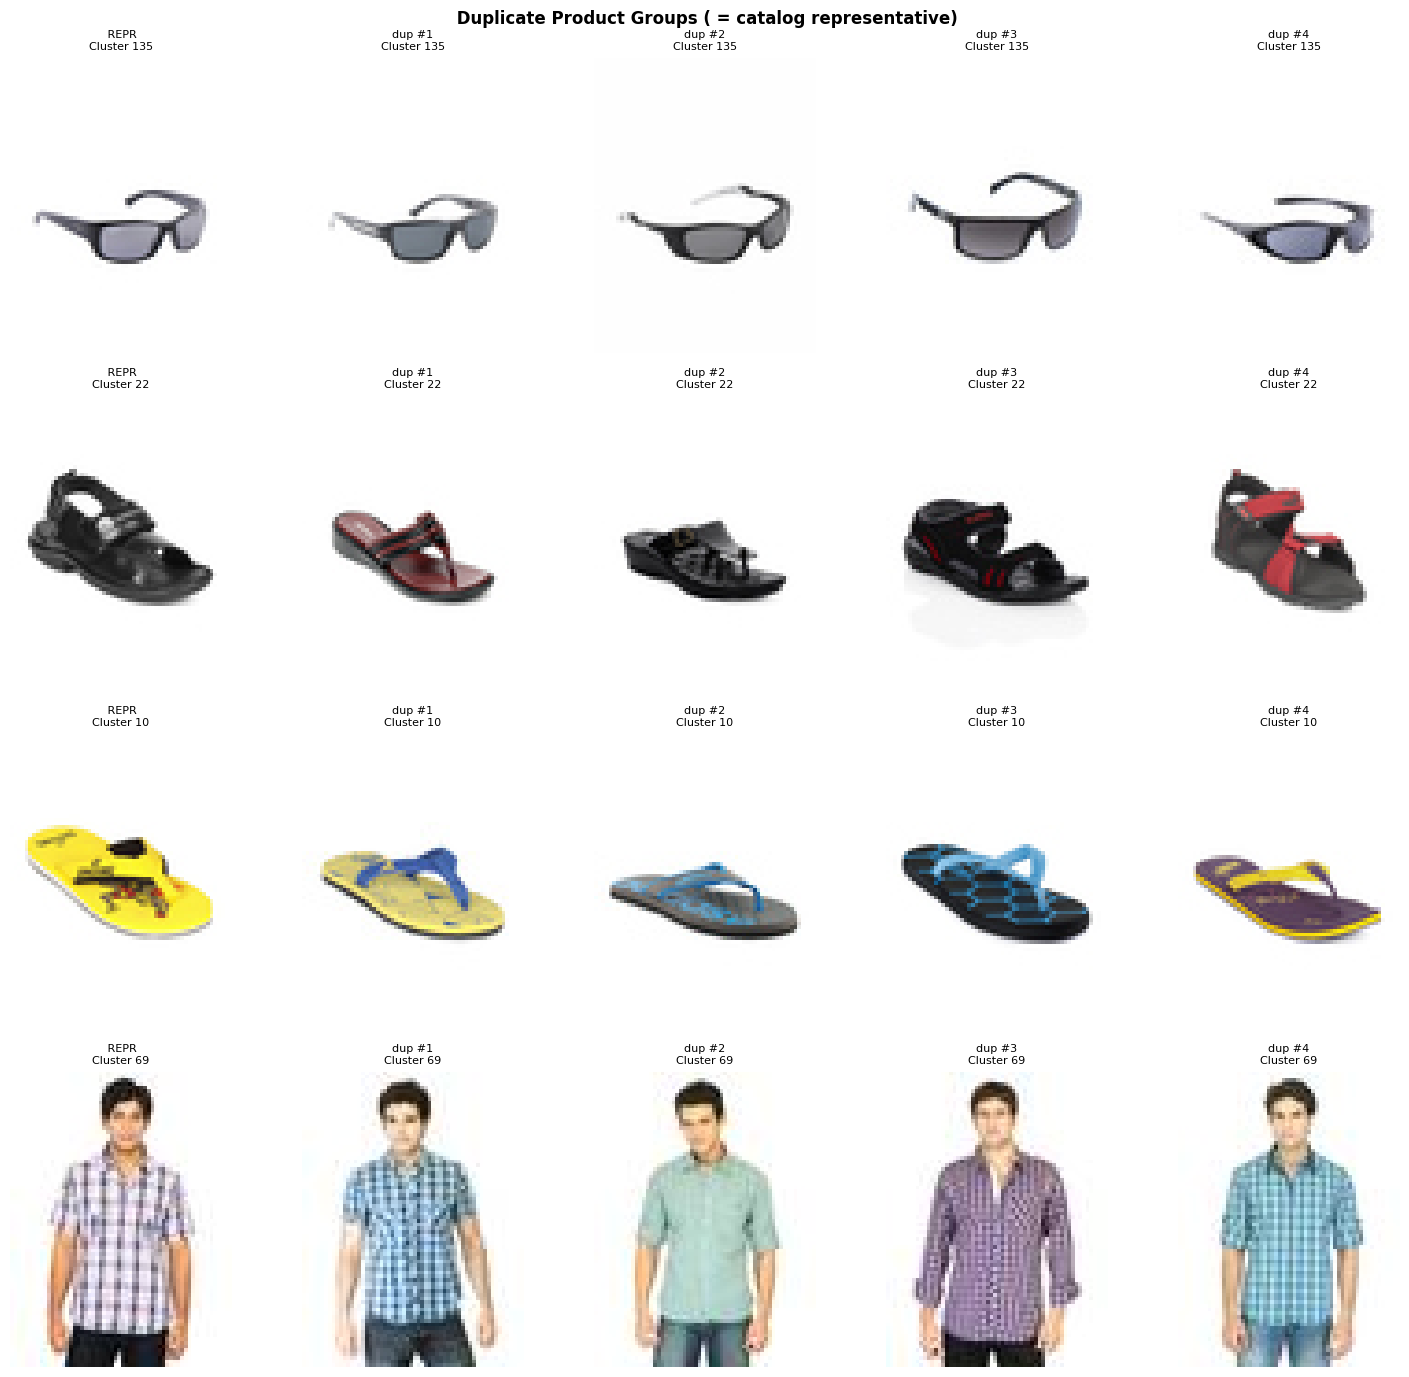

In [15]:
# ── Visualise: show some duplicate groups ────────────────────────────────────
dup_clusters = df_sub[df_sub['cluster_id'].map(df_sub['cluster_id'].value_counts()) > 1]
dup_cluster_ids = dup_clusters['cluster_id'].value_counts().head(4).index.tolist()

if dup_cluster_ids:
    fig_rows = len(dup_cluster_ids)
    max_cols = 5
    fig, axes = plt.subplots(fig_rows, max_cols, figsize=(max_cols * 3, fig_rows * 3.5))
    if fig_rows == 1:
        axes = [axes]

    for row_i, cid in enumerate(dup_cluster_ids):
        members = df_sub[df_sub['cluster_id'] == cid].reset_index(drop=True)
        for col_j in range(max_cols):
            ax = axes[row_i][col_j]
            ax.axis('off')
            if col_j < len(members):
                try:
                    img = Image.open(members.iloc[col_j]['image_path']).convert('RGB')
                    ax.imshow(img)
                    label = ' REPR' if col_j == 0 else f'dup #{col_j}'
                    ax.set_title(label + f'\nCluster {cid}', fontsize=8)
                except Exception:
                    pass

    plt.suptitle(' Duplicate Product Groups ( = catalog representative)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('task2_deduplication.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No duplicate clusters found at this threshold — try lowering SIMILARITY_THRESHOLD.')

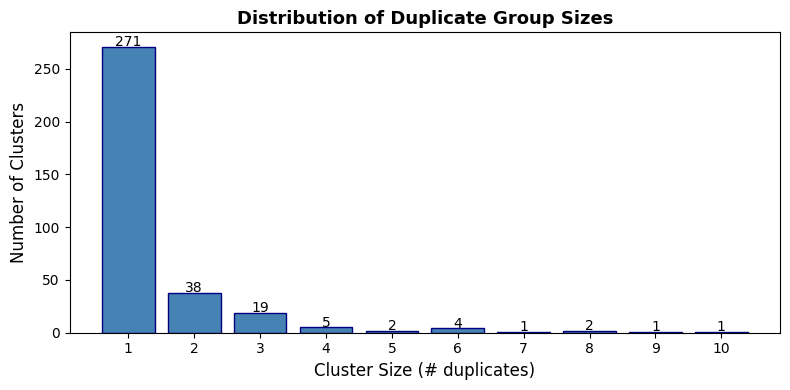


Summary:
  Total products   : 500
  Unique clusters  : 344
  Duplicates removed: 156


In [16]:
# ── Cluster-size distribution plot ────────────────────────────────────────────
cluster_sizes = df_sub['cluster_id'].value_counts().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color='steelblue', edgecolor='navy')
ax.set_xlabel('Cluster Size (# duplicates)', fontsize=12)
ax.set_ylabel('Number of Clusters', fontsize=12)
ax.set_title('Distribution of Duplicate Group Sizes', fontsize=13, fontweight='bold')
for i, v in enumerate(cluster_sizes.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('task2_cluster_distribution.png', dpi=150)
plt.show()

print(f'\nSummary:')
print(f'  Total products   : {len(df_sub)}')
print(f'  Unique clusters  : {n_clusters}')
print(f'  Duplicates removed: {len(df_sub) - n_clusters}')

---
# Task 3 – Reverse Product Search (Text → Products) 

**Approach:**  
CLIP creates embeddings in a **shared text-image space**, so a text query and a product image can be directly compared via cosine similarity.  
Steps:
1. Encode the user's text query with CLIP's text encoder.
2. Search the FAISS index (built on image embeddings) for the closest matches.
3. Return and display the top-k matching products.



🔍 Query: "blue casual shirt for men"
Top 5 Matching Products:
  1. Myntra Men Blue Shirt                          [score=0.3323]
  2. John Miller Men Blue Shirt                     [score=0.3241]
  3. Scullers Men Scul Purple Shirts                [score=0.3231]
  4. Proline Mens Solid Blue Polo Tshirt            [score=0.3218]
  5. Turtle Men Check Green Shirt                   [score=0.3195]


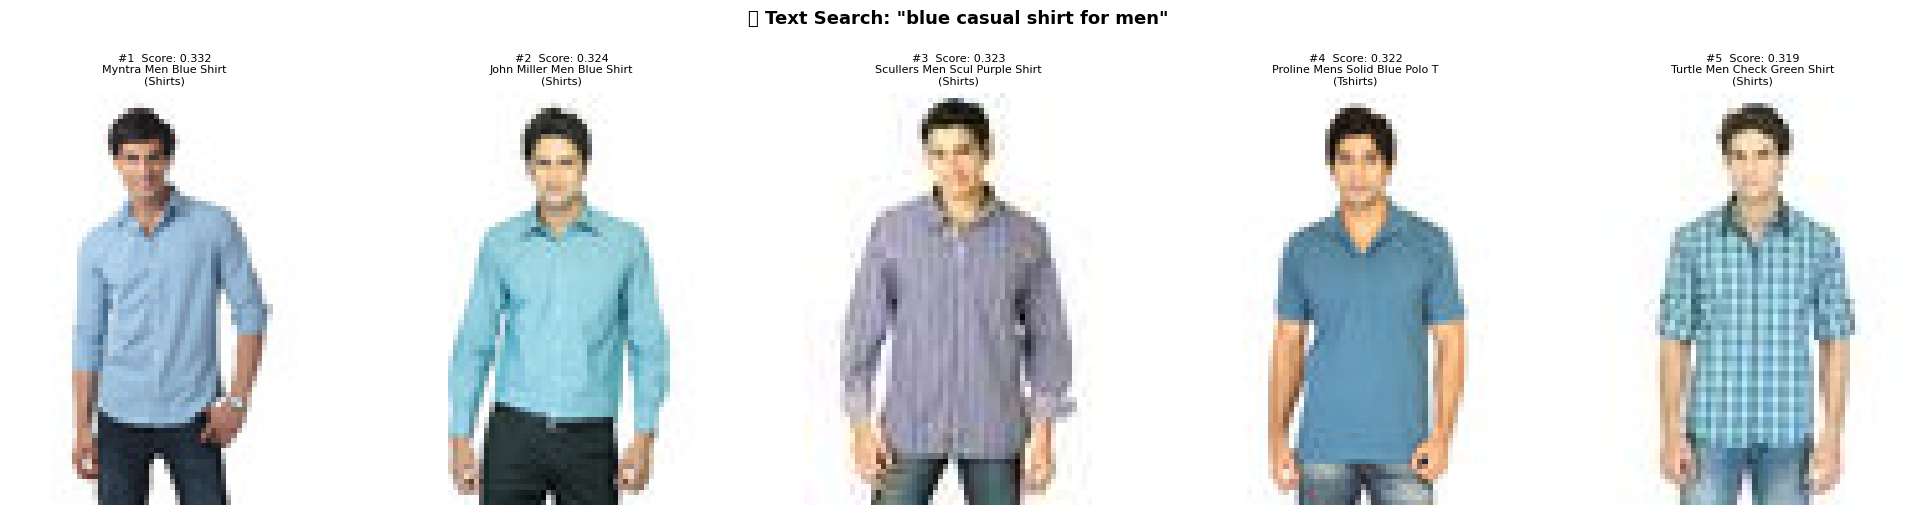


🔍 Query: "white running shoes"
Top 5 Matching Products:
  1. Asics Women Sport Gel Pulse 2 Blue White Shoe  [score=0.3128]
  2. Reebok Men Hex Express LP White Sports Shoes   [score=0.2970]
  3. Force 10 Women White Shoes                     [score=0.2943]
  4. Lotto Men White Sports Shoes                   [score=0.2921]
  5. Force 10 Men White Sports Shoes                [score=0.2906]


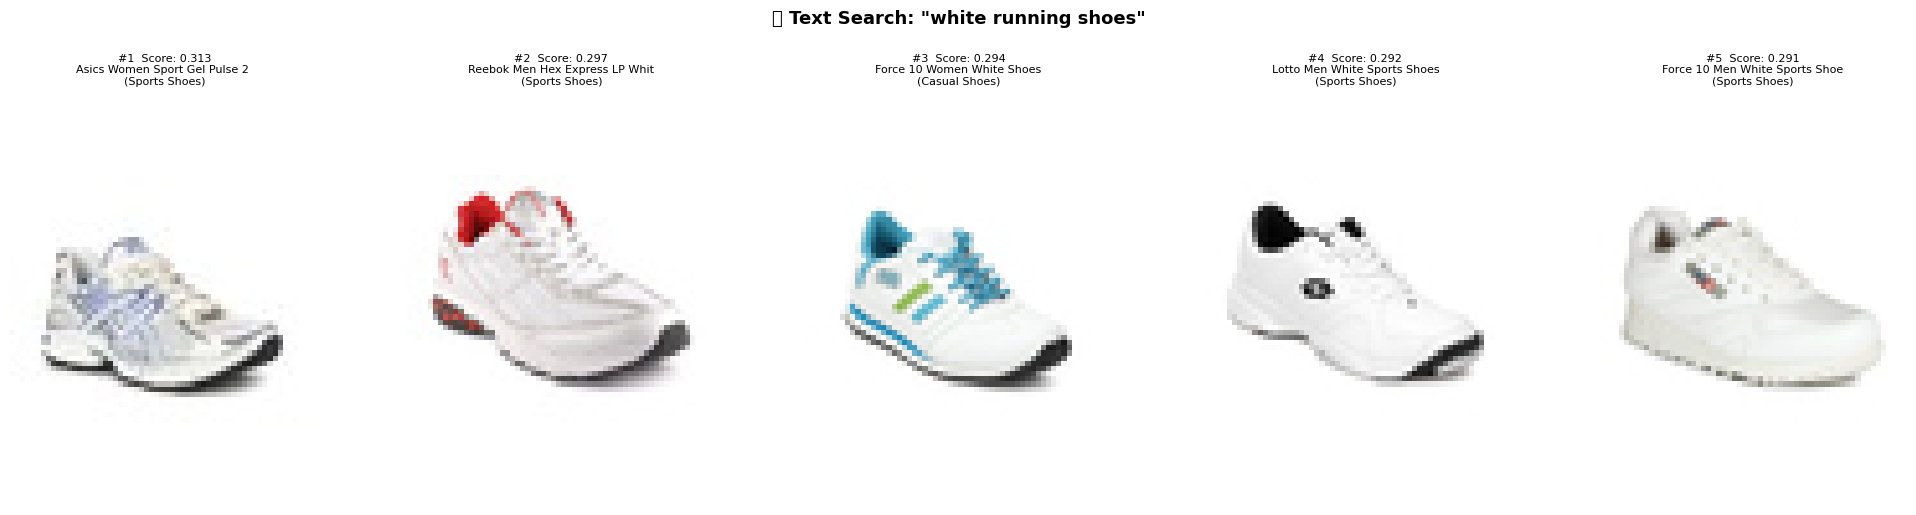


🔍 Query: "red dress for women"
Top 5 Matching Products:
  1. Alma Women Red Printed Kurta                   [score=0.3182]
  2. Fabindia Women Fushsia Pink Kurta              [score=0.2955]
  3. AND by Anita Dongre Women Printed Red Dresses  [score=0.2826]
  4. Vishudh Women Red Printed Kurta                [score=0.2818]
  5. Fabindia Women Purple Silk Kurti               [score=0.2814]


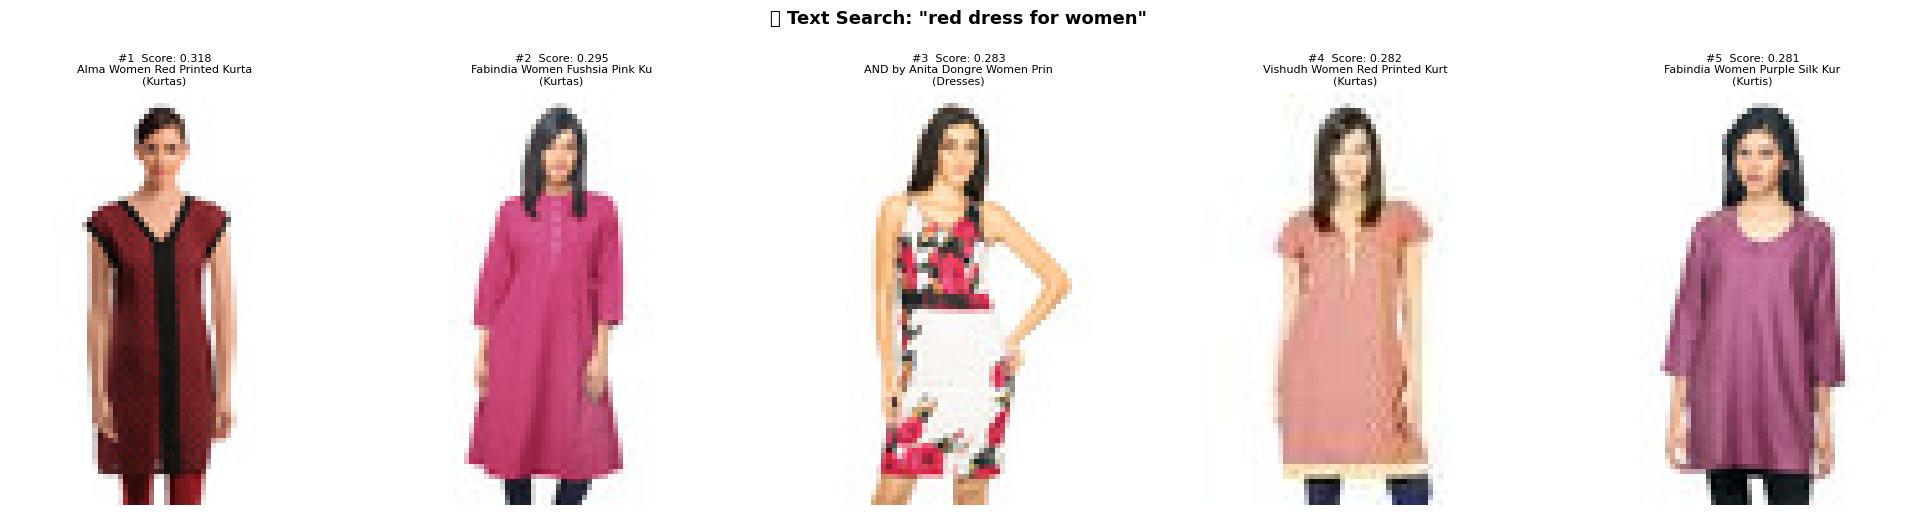


🔍 Query: "black leather wallet"
Top 5 Matching Products:
  1. Arrow Men Black Wallet                         [score=0.3419]
  2. Fossil Men Brown Wallet                        [score=0.3088]
  3. Hidekraft Men Brown Wallet                     [score=0.3065]
  4. United Colors of Benetton Men Solid Green Passport Holder  [score=0.2974]
  5. Fossil Men Marcus Brown Wallet                 [score=0.2910]


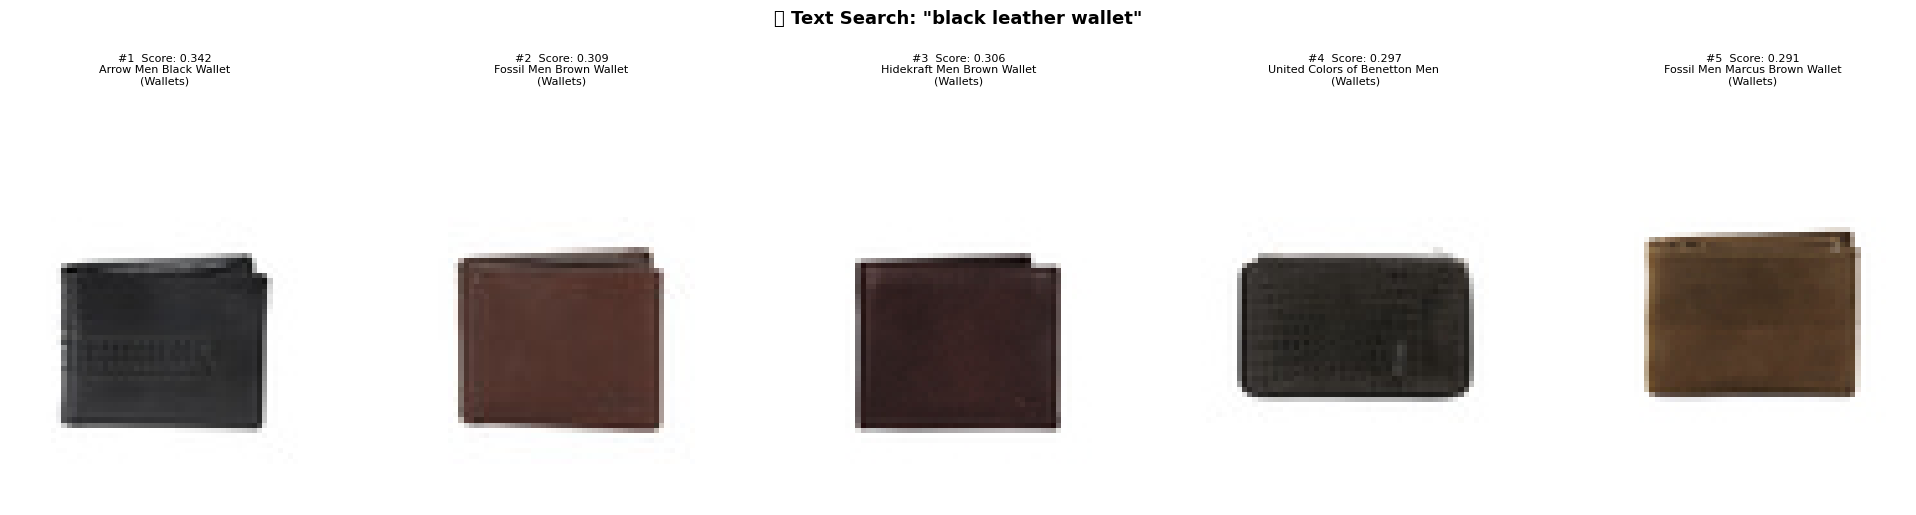

In [17]:
def text_to_product_search(query: str, df_catalog, top_k: int = 5):
    """
    Search the product catalog using a natural-language text query.
    Returns a DataFrame of the top-k matching products.
    """
    # Encode query
    text_emb = embed_texts([query]).astype('float32')

    # FAISS search
    scores, indices = faiss_index.search(text_emb, top_k)

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = df_catalog.iloc[idx]
        results.append({
            'rank':          rank,
            'product_idx':   idx,
            'name':          row.get('productDisplayName', '?'),
            'category':      row.get('masterCategory', ''),
            'subCategory':   row.get('subCategory', ''),
            'article_type':  row.get('articleType', ''),
            'gender':        row.get('gender', ''),
            'score':         float(score),
            'image_path':    row['image_path'],
        })
    return pd.DataFrame(results)


def visualize_text_search(query: str, df_catalog, top_k: int = 5):
    results = text_to_product_search(query, df_catalog, top_k)

    print(f'\n🔍 Query: "{query}"')
    print(f'Top {top_k} Matching Products:')
    for _, r in results.iterrows():
        print(f"  {r['rank']}. {r['name']:<45}  [score={r['score']:.4f}]")

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 5))
    if top_k == 1:
        axes = [axes]

    for ax, (_, r) in zip(axes, results.iterrows()):
        try:
            img = Image.open(r['image_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (200, 200, 200))
        ax.imshow(img)
        ax.set_title(
            f'#{r["rank"]}  Score: {r["score"]:.3f}\n{str(r["name"])[:30]}\n({r["article_type"]})',
            fontsize=8
        )
        ax.axis('off')

    plt.suptitle(f'🔍 Text Search: "{query}"', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    safe_name = query.replace(' ', '_')[:30]
    plt.savefig(f'task3_search_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return results


# ── Demo searches ─────────────────────────────────────────────────────────────
queries = [
    'blue casual shirt for men',
    'white running shoes',
    'red dress for women',
    'black leather wallet',
]

all_results = {}
for q in queries:
    all_results[q] = visualize_text_search(q, df_sub, top_k=5)


🔍 Query: "formal black leather shoes"
Top 5 Matching Products:
  1. Homme Men Black Semi Formal Shoes              [score=0.3243]
  2. Provogue Men Black Formal Shoes                [score=0.3124]
  3. Red Chief Men Black Shoes                      [score=0.3119]
  4. Franco Leone Men Formal Black Formal Shoes     [score=0.2990]
  5. Red Chief Men Black Sandals                    [score=0.2896]


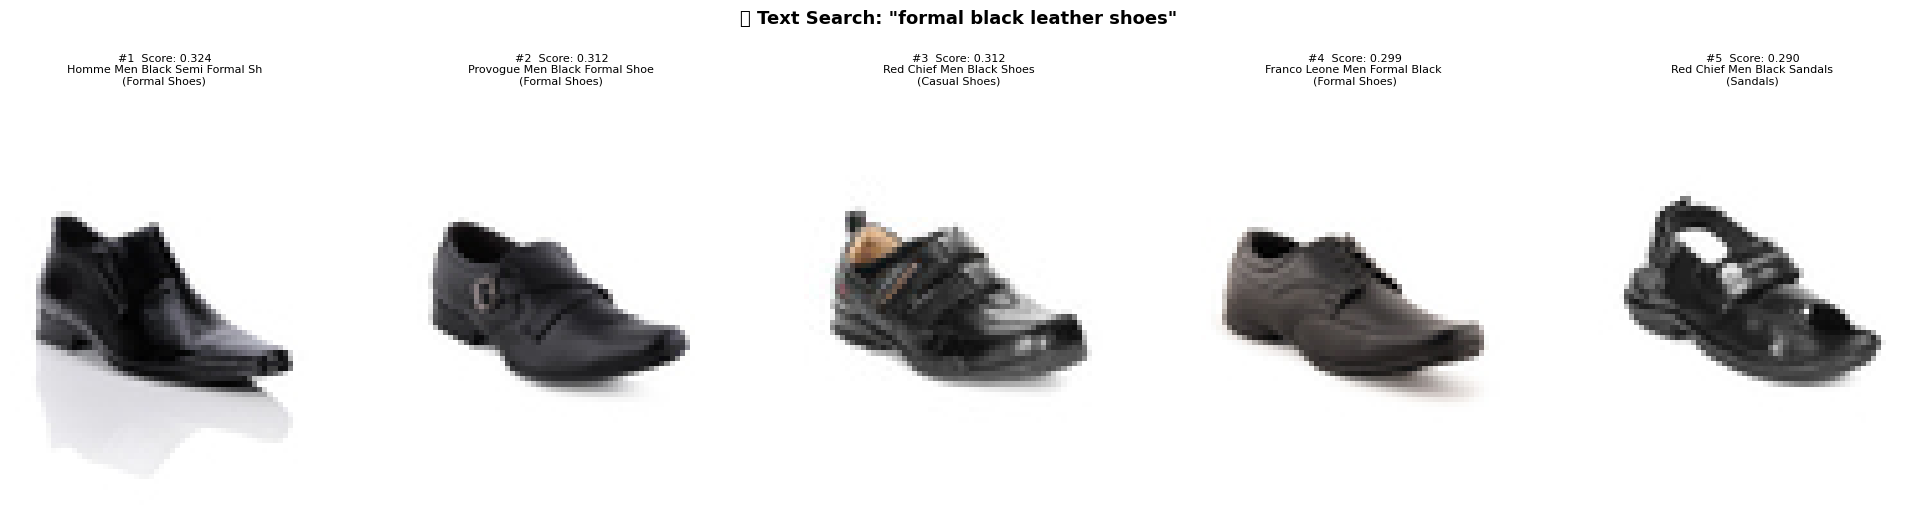

,rank,product_idx,name,category,subCategory,article_type,gender,score,image_path
0,1,244,Homme Men Black Semi Formal Shoes,Footwear,Shoes,Formal Shoes,Men,0.324304,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,2,151,Provogue Men Black Formal Shoes,Footwear,Shoes,Formal Shoes,Men,0.312421,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,3,398,Red Chief Men Black Shoes,Footwear,Shoes,Casual Shoes,Men,0.311911,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,4,57,Franco Leone Men Formal Black Formal Shoes,Footwear,Shoes,Formal Shoes,Men,0.299034,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,5,84,Red Chief Men Black Sandals,Footwear,Sandal,Sandals,Men,0.289582,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [18]:
# ── Interactive search (run this cell repeatedly with different queries) ──────
USER_QUERY = 'formal black leather shoes'  # ← change me!
visualize_text_search(USER_QUERY, df_sub, top_k=5)

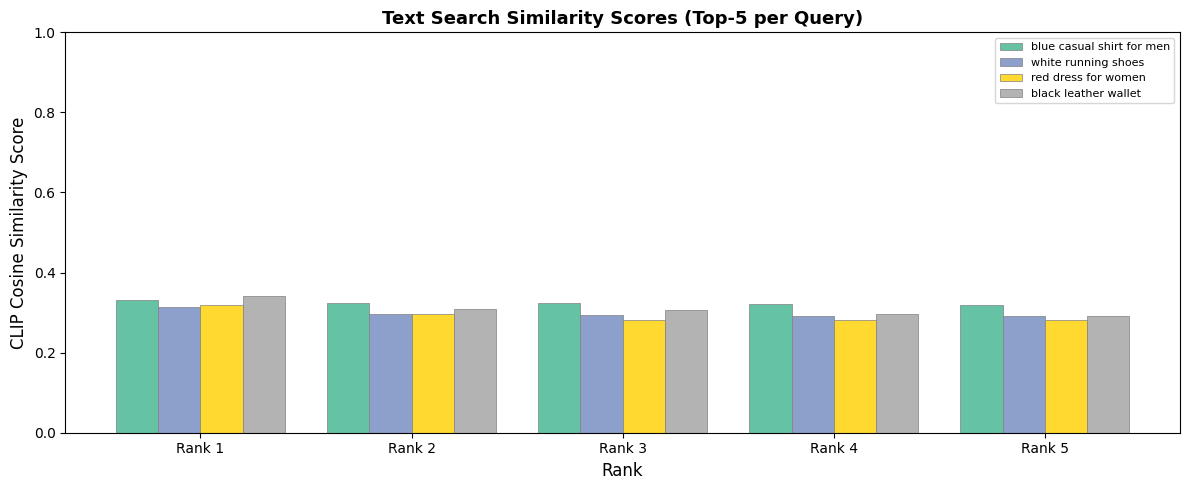

In [19]:
# ── Similarity score comparison across queries ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(queries)))

x = np.arange(5)  # top-5 ranks
width = 0.8 / len(queries)

for i, (q, res) in enumerate(all_results.items()):
    ax.bar(x + i * width, res['score'].values, width, label=q[:35], color=colors[i], edgecolor='grey', linewidth=0.5)

ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('CLIP Cosine Similarity Score', fontsize=12)
ax.set_title('Text Search Similarity Scores (Top-5 per Query)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * (len(queries) - 1) / 2)
ax.set_xticklabels([f'Rank {i+1}' for i in range(5)])
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('task3_score_comparison.png', dpi=150)
plt.show()